In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#!pip install -U kagglehub -q

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grouplens/movielens-20m-dataset")

print("Path to dataset files:", path)

100%|██████████| 195M/195M [00:02<00:00, 100MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/grouplens/movielens-20m-dataset/versions/1


In [4]:
import os

print(os.listdir(path))

['link.csv', 'genome_tags.csv', 'rating.csv', 'genome_scores.csv', 'tag.csv', 'movie.csv']


In [5]:
movies = pd.read_csv(path + "/movie.csv")
ratings = pd.read_csv(path + "/rating.csv")
tags = pd.read_csv(path + "/tag.csv")

In [6]:
print(movies.columns)
print(ratings.columns)
print(tags.columns)

Index(['movieId', 'title', 'genres'], dtype='object')
Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')


# For current analysis, we will remove timestamp

In [7]:
movies.head(2)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy


In [8]:
ratings.head(2)

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16


In [9]:
tags.head(2)

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18


timestamp present in ratings and tags both dataset , and not work on timestamp in this project

In [10]:
del ratings['timestamp']
del tags['timestamp']

In [11]:
ratings.head(2)

,userId,movieId,rating
0,1,2,3.5
1,1,29,3.5


# Series

In [12]:
row_0 = tags.iloc[0]
type(row_0)

pandas.core.series.Series

In [13]:
row_0

,0
userId,18
movieId,4141
tag,Mark Waters


In [14]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='object')

In [15]:
row_0['userId']

np.int64(18)

In [16]:
'ratings' in row_0

False

In [17]:
row_0.name

0

In [18]:
row_0 = row_0.rename('first_row')
row_0.name

'first_row'

# **DataFrames**

In [19]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [20]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [21]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [22]:
ratings.index

RangeIndex(start=0, stop=20000263, step=1)

In [23]:
tags.iloc[ [0,11,500,501] ]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue
501,342,55908,Excellent use of dialogue


# **Descriptive Statistics Let's look how the ratings are distributed!**

In [24]:
ratings['rating'].describe()

,rating
count,2.000026e+07
mean,3.525529e+00
std,1.051989e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


In [25]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [26]:
ratings['rating'].mean()

np.float64(3.5255285642993797)

In [27]:
ratings.mean()

,0
userId,69045.872583
movieId,9041.567330
rating,3.525529


In [28]:
ratings['rating'].min()

0.5

In [29]:
ratings['rating'].max()

5.0

In [30]:
ratings['rating'].std()

1.051988919275684

In [31]:
ratings['rating'].mode()

,rating
0,4.0


In [32]:
ratings.corr()

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [33]:
filter1 = ratings['rating'] > 10
print(filter1)
print(filter1.any())  # means in ratings no any rating is more than 10

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool
False


In [34]:
filter2 = ratings['rating'] > 0
print(filter2.all())  # its mean all value are grater than 0

True


In [35]:
ratings[ratings['rating'] < 0].value_counts()

,,,count
userId,movieId,rating,


In [36]:
a = ratings['rating'] < 0
a.count()

np.int64(20000263)

In [37]:
ratings.shape

(20000263, 3)

# **Data Cleaning: Handling Missing Data**

In [38]:
movies.shape

(27278, 3)

In [39]:
movies.isnull()

,movieId,title,genres
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
27273,False,False,False
27274,False,False,False
27275,False,False,False
27276,False,False,False


In [40]:
movies.isnull().sum()
# means no null value in movies

,0
movieId,0
title,0
genres,0


In [41]:
movies.isnull().any()

,0
movieId,False
title,False
genres,False


In [42]:
movies.isnull().any().any()

np.False_

In [43]:
ratings.shape

(20000263, 3)

In [44]:
ratings.isnull().sum()
# same like movies no null value is present in ratings datasets

,0
userId,0
movieId,0
rating,0


In [45]:
ratings.isnull().value_counts()

,,,count
userId,movieId,rating,
False,False,False,20000263


In [46]:
ratings.isnull().any().any()

np.False_

In [47]:
tags.shape

(465564, 3)

In [48]:
tags.isnull().sum()
# means 16 null value present in tags dataset in tag columns

,0
userId,0
movieId,0
tag,16


In [49]:
tags.isnull().value_counts()

userId  movieId  tag  
False   False    False    465548
                 True         16
Name: count, dtype: int64

In [50]:
tags.isnull().any().any()

np.True_

# **To remove null value from tags**

In [51]:
tags = tags.dropna()
# all null value are removed

In [52]:
tags.isnull().value_counts()

,,,count
userId,movieId,tag,
False,False,False,465548


In [53]:
tags.isnull().sum() # no null value is present

,0
userId,0
movieId,0
tag,0


In [54]:
tags.isnull().any().any()

np.False_

In [55]:
tags.shape
# shape are differend from privious shape because we remove the null value
# and 16 null value are present (465564 - 16) = 465548

(465548, 3)

In [56]:
465564 - 16 # previous shape - null value

465548

# Thats nice ! No NULL values ! Notice the number of lines have reduced

# ***Data Visualization***

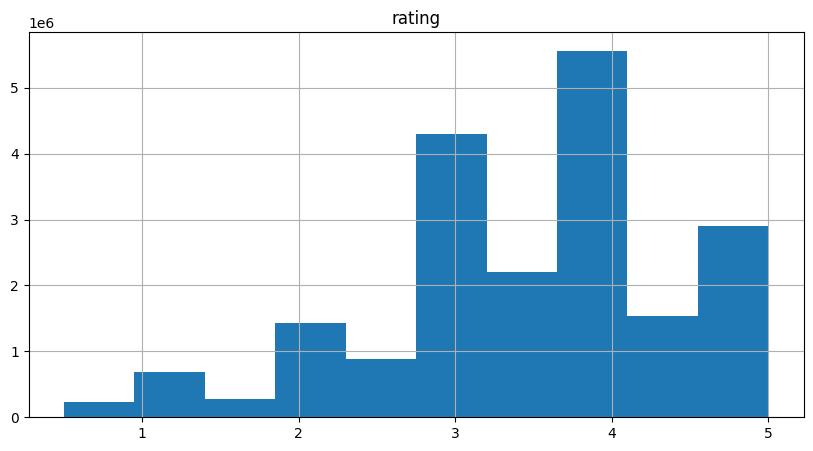

In [57]:
%matplotlib inline
ratings.hist(column = 'rating', figsize=(10,5))
plt.show()

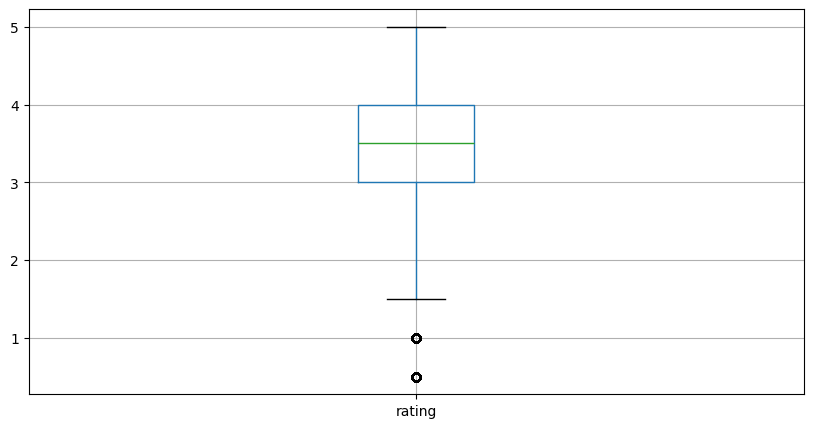

In [58]:
ratings.boxplot(column = 'rating', figsize=(10,5))
plt.show()

# **Slicing Out Columns**

In [59]:
tags['tag'].head()

,tag
0,Mark Waters
1,dark hero
2,dark hero
3,noir thriller
4,dark hero


In [60]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [61]:
ratings[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [62]:
ratings['rating'].min()

0.5

In [78]:
t= tags['tag'].unique().tolist()

len(t)

38643

In [68]:
tags.tail(10)

,userId,movieId,tag
465554,138446,3489,visually appealing
465555,138446,7045,family friendly
465556,138446,7045,Scary Movies To See on Halloween
465557,138446,7164,Peter Pan
465558,138446,7164,visually appealing
465559,138446,55999,dragged
465560,138446,55999,Jason Bateman
465561,138446,55999,quirky
465562,138446,55999,sad
465563,138472,923,rise to power


In [66]:
tag_count = tags['tag'].value_counts()
tag_count[-10:]

,count
tag,
Hell naw,1
This is my happy face,1
I heel toe on Uday's house,1
Why?,1
Bobo,1
Diamond Dallas Page,1
I'm Devon Butler!,1
No arguement,1
Really Bad,1


In [80]:
tags['tag'].value_counts()[-10:]

,count
tag,
Hell naw,1
This is my happy face,1
I heel toe on Uday's house,1
Why?,1
Bobo,1
Diamond Dallas Page,1
I'm Devon Butler!,1
No arguement,1
Really Bad,1


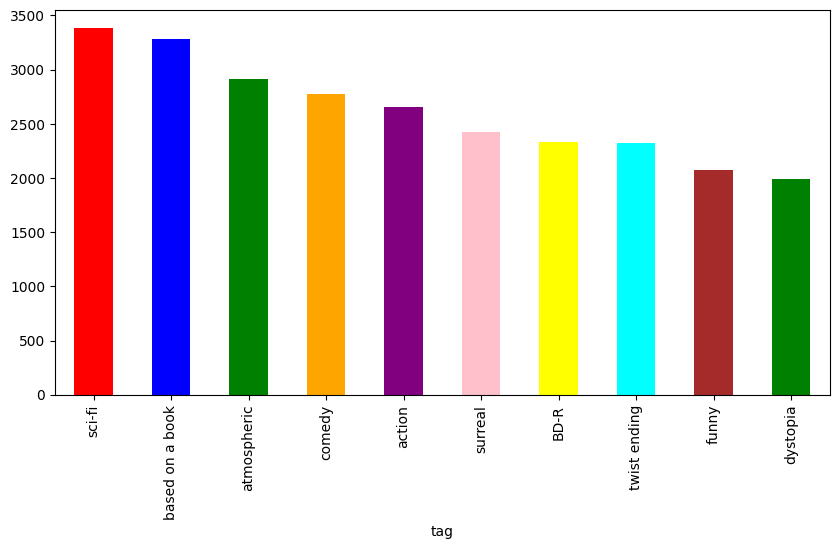

In [90]:
tag_count[:10].plot(kind='bar', figsize=(10,5),color=['red', 'blue', 'green', 'orange', 'purple',
           'pink', 'yellow', 'cyan', 'brown','green'])
plt.show()

In [91]:
# plt.plot? to know about this

# **Filters for Selecting Rows**

In [101]:
# we find five and more than five rating
highly_rating = ratings['rating'] >= 5.0
ratings[highly_rating][30:50]

,userId,movieId,rating
239,3,50,5.0
242,3,175,5.0
244,3,223,5.0
245,3,260,5.0
246,3,316,5.0
247,3,318,5.0
248,3,329,5.0
252,3,457,5.0
253,3,480,5.0
254,3,490,5.0


In [100]:
ratings.query('rating >= 5.0')[30:50]

,userId,movieId,rating
239,3,50,5.0
242,3,175,5.0
244,3,223,5.0
245,3,260,5.0
246,3,316,5.0
247,3,318,5.0
248,3,329,5.0
252,3,457,5.0
253,3,480,5.0
254,3,490,5.0


In [102]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [109]:
movies.query('genres == "Action"')[5:15]

,movieId,title,genres
962,980,"Yes, Madam (a.k.a. Police Assassins) (a.k.a. I...",Action
1080,1102,American Strays (1996),Action
1087,1110,Bird of Prey (1996),Action
1147,1170,Best of the Best 3: No Turning Back (1995),Action
1390,1424,Inside (1996),Action
1400,1434,"Stranger, The (1994)",Action
1454,1497,Double Team (1997),Action
1547,1599,Steel (1997),Action
2112,2196,Knock Off (1998),Action
2173,2258,"Master, The (1984)",Action


In [110]:
movies.query('genres.str.contains("Action")')[5:15]

,movieId,title,genres
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller
69,70,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
70,71,Fair Game (1995),Action
75,76,Screamers (1995),Action|Sci-Fi|Thriller
77,78,"Crossing Guard, The (1995)",Action|Crime|Drama|Thriller
85,86,White Squall (1996),Action|Adventure|Drama


# **Group By and Aggregate**

In [112]:
ratings.groupby('rating').agg({'movieId': 'count'})

,movieId
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


In [115]:
ratings.groupby('movieId').agg({'rating': 'mean'}).head()

,rating
movieId,
1,3.921240
2,3.211977
3,3.151040
4,2.861393
5,3.064592


In [116]:
ratings.groupby('movieId').agg({'rating': 'count'}).head()

,rating
movieId,
1,49695
2,22243
3,12735
4,2756
5,12161


In [117]:
ratings.groupby('movieId').agg({'rating': 'count'}).tail()

,rating
movieId,
131254,1
131256,1
131258,1
131260,1
131262,1


In [118]:
movie_count = ratings[['movieId','rating']].groupby('movieId').count()
movie_count.tail()

,rating
movieId,
131254,1
131256,1
131258,1
131260,1
131262,1


# **Merge Dataframes**

In [119]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [120]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [122]:
t = movies.merge(tags, on='movieId', how='left')
t.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644.0,Watched
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,computer animation
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,Disney animated feature
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,Pixar animation
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,TÃ©a Leoni does not star in this movie


In [123]:
t = movies.merge(tags, on='movieId', how='inner')
t.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644,Watched
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,computer animation
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Disney animated feature
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Pixar animation
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,TÃ©a Leoni does not star in this movie


In [125]:
t = movies.merge(tags, on='movieId', how='outer')
t.head()

,movieId,title,genres,userId,tag
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644.0,Watched
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,computer animation
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,Disney animated feature
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,Pixar animation
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741.0,TÃ©a Leoni does not star in this movie
